# PhoBERT Official PEFT Benchmark

Notebook này chạy benchmark Full Fine-Tuning, LoRA và DoRA official PEFT cho PhoBERT trên UIT-ViON. Kết quả được ghi vào `results/offical_benchmark_result.csv` với schema giống `results/benchmark_results_2.csv`.

In [ ]:
from pathlib import Path
import csv
import inspect
import itertools
import json
import os
import platform
import random
import sys
import time
from typing import Any

if sys.platform.startswith('win'):
    import asyncio
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS = ROOT / 'results' / 'offical_benchmark_result.csv'
REFERENCE_RESULTS = ROOT / 'results' / 'benchmark_results_2.csv'
OUTPUT_ROOT = ROOT / 'outputs'
MODEL_NAME = 'vinai/phobert-base-v2'
DATASET = 'data/uit_vion/subset.csv'
DATASET_PATH = ROOT / DATASET
TARGET_MODULES = ['query', 'value']
RESULT_COLUMNS = [
    'run_id', 'method', 'model_name', 'dataset', 'task_type', 'rank', 'alpha', 'dropout', 'seed',
    'init_magnitude', 'use_detached_gradient', 'accuracy', 'micro_f1', 'macro_f1', 'weighted_f1',
    'samples_f1', 'hamming_loss', 'label_threshold', 'trainable_params', 'total_params',
    'trainable_percent', 'train_time_sec', 'peak_vram_mb', 'checkpoint_size_mb', 'output_dir',
]

ROOT, RESULTS

## Dependency Check

In [ ]:
import peft
from peft import LoraConfig, TaskType, get_peft_model

version_parts = tuple(int(part) for part in peft.__version__.split('.')[:2])
assert version_parts >= (0, 19), f'Need peft>=0.19 for official DoRA support, found {peft.__version__}'
assert 'use_dora' in inspect.signature(LoraConfig.__init__).parameters
print('PEFT:', peft.__version__)
print('PEFT path:', peft.__file__)
print('Official DoRA available:', 'use_dora' in inspect.signature(LoraConfig.__init__).parameters)

## GPU Diagnostics

In [ ]:
import torch

print('Python:', sys.executable)
print('Platform:', platform.platform())
print('PyTorch:', torch.__version__)
print('PyTorch CUDA build:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
print('CUDA device count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    major, minor = torch.cuda.get_device_capability(0)
    print('Compute capability:', f'{major}.{minor}')
else:
    print('This environment is using CPU-only PyTorch or cannot access CUDA.')
    print('Install a CUDA-enabled PyTorch wheel in this exact environment:')
    print(f'{sys.executable} -m pip install --upgrade --index-url https://download.pytorch.org/whl/cu129 torch torchvision torchaudio')

## Download Model and Dataset

In [ ]:
DOWNLOAD_ASSETS = False
DATASET_NAME = 'uitnlp/vietnamese_students_feedback'
LOCAL_FILES_ONLY = False
FORCE_DOWNLOAD = False

if DOWNLOAD_ASSETS:
    os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')
    from datasets import load_dataset
    from huggingface_hub import snapshot_download
    from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer

    model_cache_dir = snapshot_download(
        repo_id=MODEL_NAME,
        local_files_only=LOCAL_FILES_ONLY,
        force_download=FORCE_DOWNLOAD,
    )
    tokenizer = AutoTokenizer.from_pretrained(model_cache_dir, use_fast=False, local_files_only=True)
    config = AutoConfig.from_pretrained(model_cache_dir, num_labels=3, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_cache_dir,
        config=config,
        local_files_only=True,
        ignore_mismatched_sizes=True,
    )
    dataset = load_dataset(DATASET_NAME, trust_remote_code=True)
    print('PhoBERT cache:', model_cache_dir)
    print('Tokenizer vocab size:', len(tokenizer))
    print('Model loaded:', type(model).__name__)
    print(dataset)
else:
    print('Set DOWNLOAD_ASSETS = True to download PhoBERT and UIT-VSFC into the local Hugging Face cache.')

## Training Helpers

In [ ]:
import numpy as np
from transformers import AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments

from src.models import build_phobert_classifier
from src.peft import count_parameters
from train import (
    compute_metrics,
    directory_size_mb,
    load_named_or_local_dataset,
    make_multilabel_compute_metrics,
    prepare_dataset,
)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def append_results(results_file: Path, row: dict[str, Any]) -> None:
    results_file.parent.mkdir(parents=True, exist_ok=True)
    file_exists = results_file.exists()
    with results_file.open('a', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=RESULT_COLUMNS)
        if not file_exists:
            writer.writeheader()
        writer.writerow({column: row.get(column, '') for column in RESULT_COLUMNS})


def configure_official_peft(model: torch.nn.Module, method: str, rank: int, alpha: float, dropout: float):
    if method == 'ft':
        for param in model.parameters():
            param.requires_grad = True
        return model, dropout

    effective_dropout = 0.0 if method == 'dora' else dropout
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=alpha,
        lora_dropout=effective_dropout,
        target_modules=TARGET_MODULES,
        bias='none',
        modules_to_save=['classifier'],
        use_dora=(method == 'dora'),
    )
    peft_model = get_peft_model(model, peft_config)
    peft_model.print_trainable_parameters()
    return peft_model, effective_dropout


def make_training_args(output_dir: Path, method: str, learning_rate: float, batch_size: int, eval_batch_size: int, epochs: float, seed: int):
    kwargs = {
        'output_dir': str(output_dir),
        'learning_rate': learning_rate,
        'per_device_train_batch_size': batch_size,
        'per_device_eval_batch_size': eval_batch_size,
        'num_train_epochs': epochs,
        'save_strategy': 'epoch' if method == 'ft' else 'no',
        'load_best_model_at_end': method == 'ft',
        'metric_for_best_model': 'macro_f1',
        'greater_is_better': True,
        'logging_steps': 50,
        'report_to': [],
        'seed': seed,
    }
    arg_names = inspect.signature(TrainingArguments.__init__).parameters
    if 'eval_strategy' in arg_names:
        kwargs['eval_strategy'] = 'epoch'
    else:
        kwargs['evaluation_strategy'] = 'epoch'
    return TrainingArguments(**kwargs)


def run_official_peft_training(
    method: str,
    seed: int,
    rank: int = 8,
    alpha: float | None = None,
    dropout: float = 0.05,
    dataset_name: str = DATASET,
    task_type: str = 'single_label',
    label_map: str | None = None,
    label_threshold: float = 0.5,
    epochs: float = 5.0,
    learning_rate: float | None = None,
    batch_size: int = 16,
    eval_batch_size: int = 32,
    max_length: int = 256,
    max_train_samples: int | None = None,
    max_eval_samples: int | None = None,
) -> dict[str, Any]:
    set_seed(seed)
    if alpha is None and method in {'lora', 'dora'}:
        alpha = 2 * rank
    if learning_rate is None:
        learning_rate = 2e-5 if method == 'ft' else 2e-4

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
    dataset, num_labels, label_map_dict = prepare_dataset(
        str(ROOT / dataset_name),
        tokenizer,
        max_length,
        max_train_samples,
        max_eval_samples,
        task_type=task_type,
        label_map_path=label_map,
    )
    id2label = {idx: label for label, idx in label_map_dict.items()}
    problem_type = 'multi_label_classification' if task_type == 'multi_label' else None
    model = build_phobert_classifier(
        MODEL_NAME,
        num_labels=num_labels,
        problem_type=problem_type,
        id2label=id2label,
        label2id=label_map_dict,
    )
    model, effective_dropout = configure_official_peft(model, method, rank, alpha or 0, dropout)
    counts = count_parameters(model)

    rank_part = f'_r{rank}' if method in {'lora', 'dora'} else ''
    run_id = f'official_{method}{rank_part}_seed{seed}_{int(time.time())}'
    output_dir = OUTPUT_ROOT / run_id
    training_args = make_training_args(output_dir, method, learning_rate, batch_size, eval_batch_size, epochs, seed)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    trainer_kwargs = {
        'model': model,
        'args': training_args,
        'train_dataset': dataset['train'],
        'eval_dataset': dataset['validation'],
        'data_collator': DataCollatorWithPadding(tokenizer),
        'compute_metrics': make_multilabel_compute_metrics(label_threshold) if task_type == 'multi_label' else compute_metrics,
    }
    trainer_arg_names = inspect.signature(Trainer.__init__).parameters
    if 'processing_class' in trainer_arg_names:
        trainer_kwargs['processing_class'] = tokenizer
    else:
        trainer_kwargs['tokenizer'] = tokenizer
    trainer = Trainer(**trainer_kwargs)
    trainer.train()
    metrics = trainer.evaluate()
    train_time = time.perf_counter() - start
    peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 * 1024) if torch.cuda.is_available() else 0.0

    output_dir.mkdir(parents=True, exist_ok=True)
    if method == 'ft':
        trainer.save_model(str(output_dir / 'checkpoint_final'))
    else:
        model.save_pretrained(str(output_dir / 'adapter_checkpoint'))

    row = {
        'run_id': run_id,
        'method': method,
        'model_name': MODEL_NAME,
        'dataset': dataset_name,
        'task_type': task_type,
        'rank': '' if method == 'ft' else rank,
        'alpha': '' if method == 'ft' else alpha,
        'dropout': '' if method == 'ft' else effective_dropout,
        'seed': seed,
        'init_magnitude': '',
        'use_detached_gradient': '',
        'accuracy': metrics.get('eval_accuracy'),
        'micro_f1': metrics.get('eval_micro_f1'),
        'macro_f1': metrics.get('eval_macro_f1'),
        'weighted_f1': metrics.get('eval_weighted_f1'),
        'samples_f1': metrics.get('eval_samples_f1'),
        'hamming_loss': metrics.get('eval_hamming_loss'),
        'label_threshold': label_threshold if task_type == 'multi_label' else '',
        'trainable_params': counts.trainable,
        'total_params': counts.total,
        'trainable_percent': counts.trainable_percent,
        'train_time_sec': train_time,
        'peak_vram_mb': peak_vram_mb,
        'checkpoint_size_mb': directory_size_mb(output_dir),
        'output_dir': str(output_dir.relative_to(ROOT) if output_dir.is_relative_to(ROOT) else output_dir),
    }
    with (output_dir / 'metrics.json').open('w', encoding='utf-8') as handle:
        json.dump(row, handle, indent=2, ensure_ascii=False)
    with (output_dir / 'config.json').open('w', encoding='utf-8') as handle:
        json.dump(
            {
                'method': method,
                'model_name': MODEL_NAME,
                'dataset': dataset_name,
                'task_type': task_type,
                'rank': rank,
                'alpha': alpha,
                'dropout': effective_dropout,
                'seed': seed,
                'target_modules': TARGET_MODULES,
                'official_peft': method in {'lora', 'dora'},
                'use_dora': method == 'dora',
                'modules_to_save': ['classifier'] if method in {'lora', 'dora'} else [],
                'num_labels': num_labels,
                'label_map': label_map_dict,
            },
            handle,
            indent=2,
            ensure_ascii=False,
        )
    append_results(RESULTS, row)
    print(json.dumps(row, indent=2, ensure_ascii=False))
    return row

## Run Benchmark

In [ ]:
RUN_DIRECT_CHECK = True
RUN_TRAINING = False
TRAIN_MODE = 'benchmark'  # 'single', 'smoke', or 'benchmark'
seeds = [97, 98, 99]
ranks = [8, 16]

def build_run_specs():
    specs = []
    for seed in seeds:
        specs.append({'method': 'ft', 'seed': seed})
        for method, rank in itertools.product(['lora', 'dora'], ranks):
            specs.append({'method': method, 'seed': seed, 'rank': rank, 'alpha': 2 * rank, 'dropout': 0.05})
    return specs

benchmark_specs = build_run_specs()
if TRAIN_MODE == 'single':
    run_specs = [{'method': 'dora', 'seed': 42, 'rank': 8, 'alpha': 16, 'dropout': 0.05, 'epochs': 1, 'max_train_samples': 64, 'max_eval_samples': 64}]
elif TRAIN_MODE == 'smoke':
    run_specs = [{**spec, 'epochs': 1, 'max_train_samples': 64, 'max_eval_samples': 64} for spec in benchmark_specs[:3]]
elif TRAIN_MODE == 'benchmark':
    run_specs = benchmark_specs
else:
    raise ValueError("TRAIN_MODE must be 'single', 'smoke', or 'benchmark'")

if RUN_DIRECT_CHECK:
    assert RESULTS.name == 'offical_benchmark_result.csv'
    assert RESULT_COLUMNS == list(__import__('pandas').read_csv(REFERENCE_RESULTS, nrows=0).columns)
    assert DATASET_PATH.exists(), f'Missing dataset: {DATASET_PATH}'
    print('Direct check passed.')
    print('Rows planned:', len(run_specs))
    for spec in run_specs:
        print(spec)

if RUN_TRAINING:
    for spec in run_specs:
        run_official_peft_training(**spec)
else:
    print('Set RUN_TRAINING = True to execute the training specs above.')

## Aggregate Results

In [45]:
import pandas as pd
from IPython.display import display

df = pd.read_csv(RESULTS) if RESULTS.exists() else pd.DataFrame(columns=RESULT_COLUMNS)
if df.empty or df.dropna(how='all').empty:
    print(f'No benchmark rows found yet: {RESULTS}')
    print('Set RUN_TRAINING = True above, then rerun this notebook.')
else:
    assert list(df.columns) == RESULT_COLUMNS
    df = df.dropna(subset=['method'], how='any')
display(df)

,run_id,method,model_name,dataset,task_type,rank,alpha,dropout,seed,init_magnitude,...,samples_f1,hamming_loss,label_threshold,trainable_params,total_params,trainable_percent,train_time_sec,peak_vram_mb,checkpoint_size_mb,output_dir
0,official_ft_seed97_1781760636,ft,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,NaN,NaN,NaN,97,NaN,...,NaN,NaN,NaN,135008269,135008269,100.000000,467.379662,2088.181641,8253.026494,outputs\official_ft_seed97_1781760636
1,official_lora_r8_seed97_1781761112,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.05,97,NaN,...,NaN,NaN,NaN,895501,135903770,0.658923,220.620261,775.865234,3.429049,outputs\official_lora_r8_seed97_1781761112
2,official_lora_r16_seed97_1781761339,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.05,97,NaN,...,NaN,NaN,NaN,1190413,136198682,0.874027,219.527590,779.568359,4.554096,outputs\official_lora_r16_seed97_1781761339
3,official_dora_r8_seed97_1781761565,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.00,97,NaN,...,NaN,NaN,NaN,913933,135922202,0.672394,350.795533,820.862305,3.502770,outputs\official_dora_r8_seed97_1781761565
4,official_dora_r16_seed97_1781761924,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.00,97,NaN,...,NaN,NaN,NaN,1208845,136217114,0.887440,362.696513,824.565430,4.627817,outputs\official_dora_r16_seed97_1781761924
5,official_ft_seed98_1781762294,ft,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,NaN,NaN,NaN,98,NaN,...,NaN,NaN,NaN,135008269,135008269,100.000000,482.320796,2090.978516,8253.026784,outputs\official_ft_seed98_1781762294
6,official_lora_r8_seed98_1781762789,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.05,98,NaN,...,NaN,NaN,NaN,895501,135903770,0.658923,277.548494,1567.559082,3.429049,outputs\official_lora_r8_seed98_1781762789
7,official_lora_r16_seed98_1781763077,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.05,98,NaN,...,NaN,NaN,NaN,1190413,136198682,0.874027,273.086400,779.568359,4.554096,outputs\official_lora_r16_seed98_1781763077
8,official_dora_r8_seed98_1781763357,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.00,98,NaN,...,NaN,NaN,NaN,913933,135922202,0.672394,368.130853,838.737305,3.502770,outputs\official_dora_r8_seed98_1781763357
9,official_dora_r16_seed98_1781763733,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.00,98,NaN,...,NaN,NaN,NaN,1208845,136217114,0.887440,410.921563,842.440430,4.627817,outputs\official_dora_r16_seed98_1781763733


In [46]:
if df.empty:
    summary = pd.DataFrame()
else:
    summary = (
        df.groupby(['method', 'rank'], dropna=False)
        .agg(
            accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
            macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
            weighted_f1_mean=('weighted_f1', 'mean'), weighted_f1_std=('weighted_f1', 'std'),
            trainable_percent_mean=('trainable_percent', 'mean'),
            peak_vram_mb_mean=('peak_vram_mb', 'mean'),
            train_time_sec_mean=('train_time_sec', 'mean'),
            checkpoint_size_mb_mean=('checkpoint_size_mb', 'mean'),
            runs=('run_id', 'count'),
        )
        .reset_index()
        .sort_values(['method', 'rank'])
    )
display(summary)

,method,rank,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,trainable_percent_mean,peak_vram_mb_mean,train_time_sec_mean,checkpoint_size_mb_mean,runs
0,dora,8.0,0.797308,0.001763,0.796700,0.001441,0.796700,0.001441,0.672394,826.820638,335.003242,3.502770,3
1,dora,16.0,0.800897,0.000801,0.800375,0.000767,0.800375,0.000767,0.887440,830.523763,353.981032,4.627817,3
2,ft,NaN,0.810897,0.001897,0.810176,0.002402,0.810176,0.002402,100.000000,2089.623698,485.343491,8253.026503,3
3,lora,8.0,0.797051,0.002502,0.796466,0.002813,0.796466,0.002813,0.658923,1303.661133,270.955364,3.429049,3
4,lora,16.0,0.802821,0.002187,0.802307,0.002003,0.802307,0.002003,0.874027,779.214193,239.379747,4.554096,3


## Plots

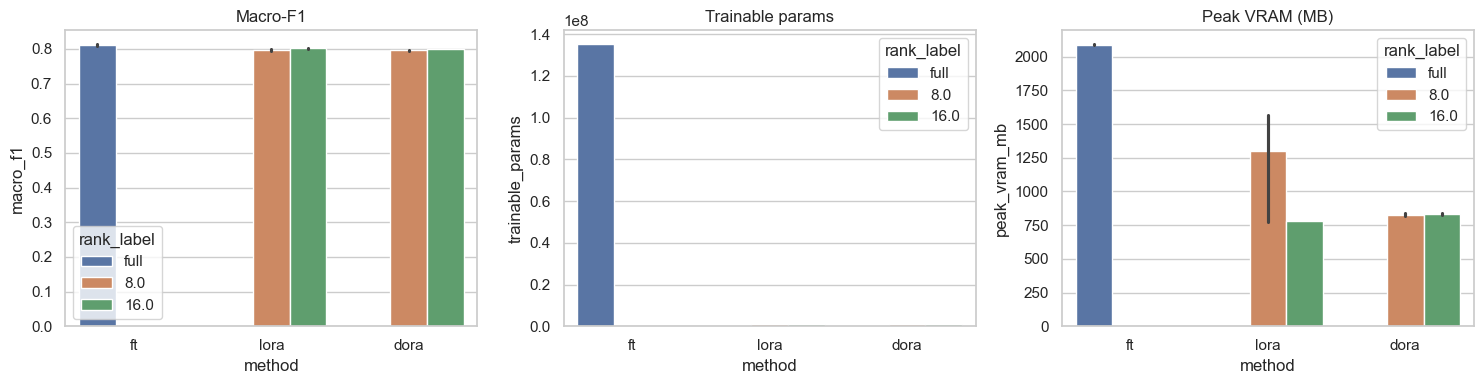

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

if df.empty:
    print('No benchmark rows to plot yet.')
else:
    plot_df = df.copy()
    plot_df['rank_label'] = plot_df['rank'].fillna('full').astype(str)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.barplot(data=plot_df, x='method', y='macro_f1', hue='rank_label', ax=axes[0])
    axes[0].set_title('Macro-F1')
    sns.barplot(data=plot_df, x='method', y='trainable_params', hue='rank_label', ax=axes[1])
    axes[1].set_title('Trainable params')
    sns.barplot(data=plot_df, x='method', y='peak_vram_mb', hue='rank_label', ax=axes[2])
    axes[2].set_title('Peak VRAM (MB)')
    plt.tight_layout()

## Paired run comparison

In [48]:
CUSTOM_RESULTS = ROOT / 'results' / 'benchmark_results_2.csv'
OFFICIAL_RESULTS = ROOT / 'results' / 'offical_benchmark_result.csv'
COMPARISON_RESULTS = ROOT / 'results' / 'official_vs_custom_comparison.csv'
SUMMARY_RESULTS = ROOT / 'results' / 'official_vs_custom_summary.csv'

custom_df = pd.read_csv(CUSTOM_RESULTS)
official_df = pd.read_csv(OFFICIAL_RESULTS)
assert list(custom_df.columns) == list(official_df.columns), 'Custom and official result schemas differ.'

PAIR_KEYS = ['method', 'rank_key', 'seed']
for frame in [custom_df, official_df]:
    frame['rank_key'] = frame['rank'].fillna(-1)
    frame['rank_label'] = frame['rank'].apply(lambda value: 'full' if pd.isna(value) else str(int(value)))
    frame['method_rank'] = frame['method'] + ' / ' + frame['rank_label']

custom_renamed = custom_df.rename(columns={column: f'{column}_custom' for column in custom_df.columns if column not in PAIR_KEYS})
official_renamed = official_df.rename(columns={column: f'{column}_official' for column in official_df.columns if column not in PAIR_KEYS})
paired_df = custom_renamed.merge(official_renamed, on=PAIR_KEYS, how='outer', indicator=True)
assert (paired_df['_merge'] == 'both').all(), paired_df['_merge'].value_counts().to_dict()
assert len(paired_df) == 15, f'Expected 15 paired runs, got {len(paired_df)}'

# Bring back readable shared keys.
paired_df['rank'] = paired_df['rank_key'].replace(-1, pd.NA)
paired_df['rank_label'] = paired_df['rank_label_custom']
paired_df['method_rank'] = paired_df['method_rank_custom']
paired_df['custom_run_id'] = paired_df['run_id_custom']
paired_df['official_run_id'] = paired_df['run_id_official']

METRICS = [
    'accuracy', 'macro_f1', 'weighted_f1',
    'trainable_params', 'total_params', 'trainable_percent',
    'train_time_sec', 'peak_vram_mb', 'checkpoint_size_mb',
]
for metric in METRICS:
    paired_df[f'{metric}_delta'] = paired_df[f'{metric}_official'] - paired_df[f'{metric}_custom']
    paired_df[f'{metric}_pct_delta'] = paired_df[f'{metric}_delta'] / paired_df[f'{metric}_custom'].replace(0, pd.NA) * 100

OUTPUT_COLUMNS = [
    'method', 'rank', 'rank_label', 'method_rank', 'seed', 'custom_run_id', 'official_run_id',
]
for metric in METRICS:
    OUTPUT_COLUMNS.extend([f'{metric}_custom', f'{metric}_official', f'{metric}_delta', f'{metric}_pct_delta'])
comparison_df = paired_df[OUTPUT_COLUMNS].sort_values(['method', 'rank_label', 'seed']).reset_index(drop=True)

summary_aggs = {}
for metric in METRICS:
    summary_aggs[f'{metric}_custom_mean'] = (f'{metric}_custom', 'mean')
    summary_aggs[f'{metric}_official_mean'] = (f'{metric}_official', 'mean')
    summary_aggs[f'{metric}_delta_mean'] = (f'{metric}_delta', 'mean')
    summary_aggs[f'{metric}_delta_std'] = (f'{metric}_delta', 'std')
summary_df = (
    comparison_df.groupby(['method', 'rank_label', 'method_rank'], dropna=False)
    .agg(**summary_aggs, runs=('seed', 'count'))
    .reset_index()
    .sort_values(['method', 'rank_label'])
)

assert len(summary_df) == 5, f'Expected 5 method/rank groups, got {len(summary_df)}'
assert not comparison_df[[f'{metric}_delta' for metric in METRICS]].isna().all().all(), 'All deltas are null.'
if not (comparison_df['trainable_params_delta'] == 0).all():
    print('Warning: trainable_params differs for at least one paired run.')

COMPARISON_RESULTS.parent.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(COMPARISON_RESULTS, index=False)
summary_df.to_csv(SUMMARY_RESULTS, index=False)
print(f'Wrote {len(comparison_df)} paired rows to {COMPARISON_RESULTS}')
print(f'Wrote {len(summary_df)} summary rows to {SUMMARY_RESULTS}')
display(comparison_df)
display(summary_df)

Wrote 15 paired rows to c:\Users\letie\OneDrive\Documents\GitHub\PEFT-from-scartch\results\official_vs_custom_comparison.csv
Wrote 5 summary rows to c:\Users\letie\OneDrive\Documents\GitHub\PEFT-from-scartch\results\official_vs_custom_summary.csv


,method,rank,rank_label,method_rank,seed,custom_run_id,official_run_id,accuracy_custom,accuracy_official,accuracy_delta,...,train_time_sec_delta,train_time_sec_pct_delta,peak_vram_mb_custom,peak_vram_mb_official,peak_vram_mb_delta,peak_vram_mb_pct_delta,checkpoint_size_mb_custom,checkpoint_size_mb_official,checkpoint_size_mb_delta,checkpoint_size_mb_pct_delta
0,dora,16.0,16,dora / 16,97,dora_r16_seed97_1781724745,official_dora_r16_seed97_1781761924,0.801923,0.801538,-0.000385,...,72.195886,24.852231,873.982910,824.565430,-49.417480,-5.654285,4.636088,4.627817,-0.008271,-0.178409
1,dora,16.0,16,dora / 16,98,dora_r16_seed98_1781726380,official_dora_r16_seed98_1781763733,0.804231,0.800000,-0.004231,...,154.742833,60.404247,874.607910,842.440430,-32.167480,-3.677932,4.636088,4.627817,-0.008271,-0.178409
2,dora,16.0,16,dora / 16,99,dora_r16_seed99_1781728011,official_dora_r16_seed99_1781765512,0.804615,0.801154,-0.003462,...,33.280669,13.048973,873.982910,824.565430,-49.417480,-5.654285,4.636088,4.627817,-0.008271,-0.178409
3,dora,8.0,8,dora / 8,97,dora_r8_seed97_1781724430,official_dora_r8_seed97_1781761565,0.803462,0.798846,-0.004615,...,48.580668,16.074877,870.607910,820.862305,-49.745605,-5.713893,3.511088,3.502770,-0.008318,-0.236905
4,dora,8.0,8,dora / 8,98,dora_r8_seed98_1781726109,official_dora_r8_seed98_1781763357,0.803077,0.797692,-0.005385,...,109.986036,42.606331,871.232910,838.737305,-32.495605,-3.729841,3.511088,3.502770,-0.008318,-0.236905
5,dora,8.0,8,dora / 8,99,dora_r8_seed99_1781727728,official_dora_r8_seed99_1781765219,0.802692,0.795385,-0.007308,...,15.664162,5.792548,870.607910,820.862305,-49.745605,-5.713893,3.511088,3.502770,-0.008318,-0.236905
6,ft,<NA>,full,ft / full,97,ft_seed97_1781723194,official_ft_seed97_1781760636,0.813077,0.813077,0.000000,...,-47.711490,-9.262727,2088.181641,2088.181641,0.000000,0.000000,8253.025409,8253.026494,0.001085,0.000013
7,ft,<NA>,full,ft / full,98,ft_seed98_1781725049,official_ft_seed98_1781762294,0.810000,0.810000,0.000000,...,-44.373941,-8.424983,2089.023438,2090.978516,1.955078,0.093588,8253.025690,8253.026784,0.001094,0.000013
8,ft,<NA>,full,ft / full,99,ft_seed99_1781726652,official_ft_seed99_1781764151,0.809615,0.809615,0.000000,...,9.086507,1.827376,2090.023438,2089.710938,-0.312500,-0.014952,8253.025135,8253.026231,0.001096,0.000013
9,lora,16.0,16,lora / 16,97,lora_r16_seed97_1781724042,official_lora_r16_seed97_1781761339,0.799615,0.800385,0.000769,...,-154.090987,-41.242860,778.502441,779.568359,1.065918,0.136919,4.558017,4.554096,-0.003921,-0.086014


,method,rank_label,method_rank,accuracy_custom_mean,accuracy_official_mean,accuracy_delta_mean,accuracy_delta_std,macro_f1_custom_mean,macro_f1_official_mean,macro_f1_delta_mean,...,train_time_sec_delta_std,peak_vram_mb_custom_mean,peak_vram_mb_official_mean,peak_vram_mb_delta_mean,peak_vram_mb_delta_std,checkpoint_size_mb_custom_mean,checkpoint_size_mb_official_mean,checkpoint_size_mb_delta_mean,checkpoint_size_mb_delta_std,runs
0,dora,16,dora / 16,0.803590,0.800897,-0.002692,0.002035,0.803176,0.800375,-0.002801,...,62.023450,874.191243,830.523763,-43.667480,9.959292,4.636088,4.627817,-0.008271,0.000000,3
1,dora,8,dora / 8,0.803077,0.797308,-0.005769,0.001387,0.802433,0.796700,-0.005733,...,47.872629,870.816243,826.820638,-43.995605,9.959292,3.511088,3.502770,-0.008318,0.000000,3
2,ft,full,ft / full,0.810897,0.810897,0.000000,0.000000,0.810176,0.810176,0.000000,...,31.872588,2089.076172,2089.623698,0.547526,1.228949,8253.025411,8253.026503,0.001092,0.000006,3
3,lora,16,lora / 16,0.798718,0.802821,0.004103,0.003109,0.798167,0.802307,0.004140,...,95.407843,776.831217,779.214193,2.382975,1.142316,4.558017,4.554096,-0.003921,0.000000,3
4,lora,8,lora / 8,0.798205,0.797051,-0.001154,0.001154,0.797615,0.796466,-0.001148,...,71.241688,773.128092,1303.661133,530.533040,458.532363,3.433017,3.429049,-0.003967,0.000000,3


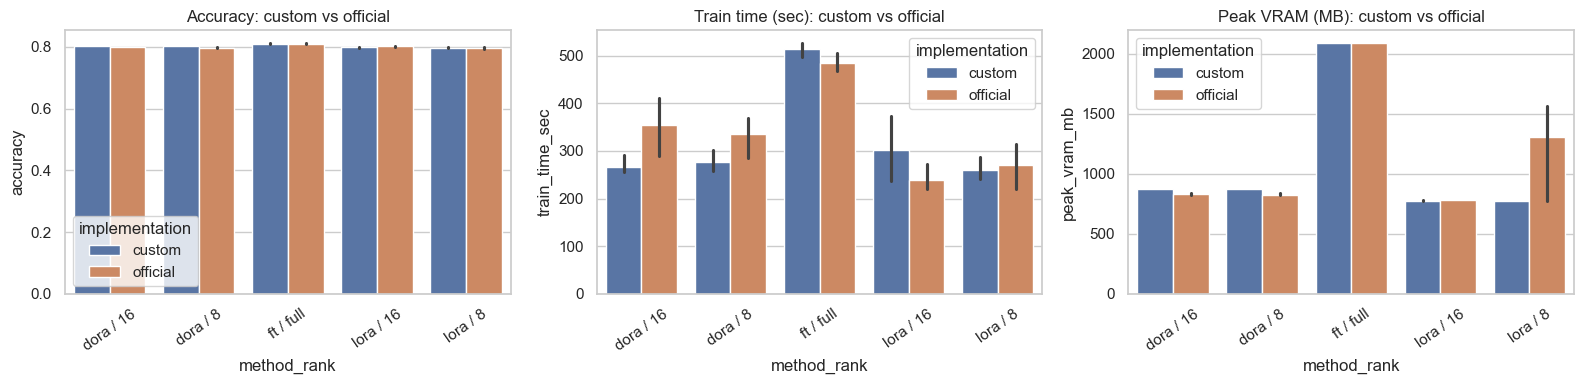

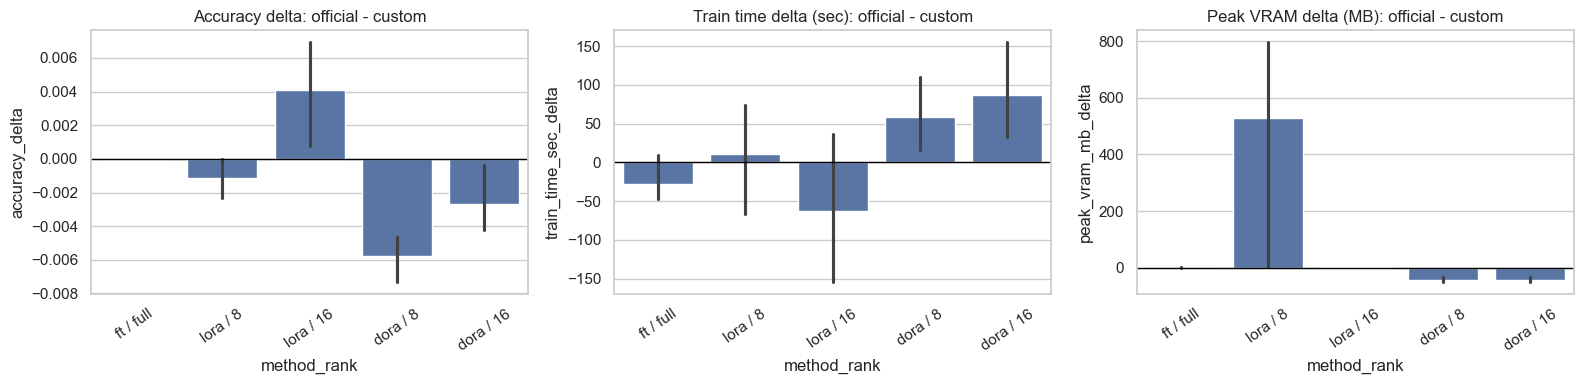

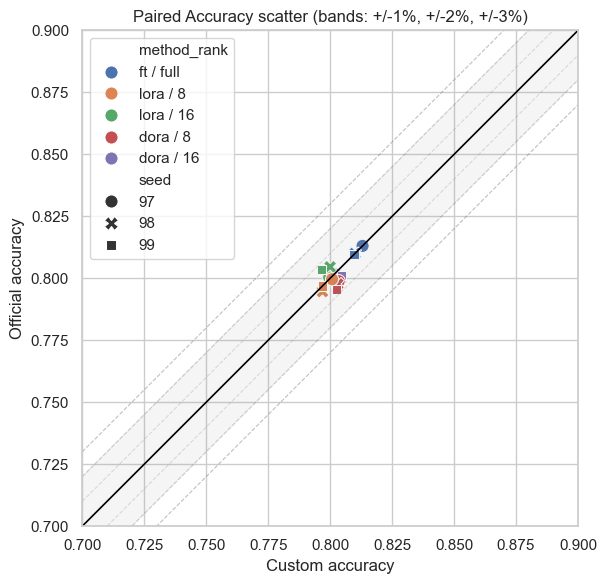

Macro-F1 columns are kept in the CSV outputs for audit, but plots focus on accuracy for this single-label benchmark.


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
method_order = ['ft / full', 'lora / 8', 'lora / 16', 'dora / 8', 'dora / 16']
plot_df = comparison_df.copy()
plot_df['method_rank'] = pd.Categorical(plot_df['method_rank'], categories=method_order, ordered=True)

paired_long = []
for _, row in plot_df.iterrows():
    for implementation in ['custom', 'official']:
        paired_long.append({
            'method_rank': row['method_rank'],
            'seed': row['seed'],
            'implementation': implementation,
            'accuracy': row[f'accuracy_{implementation}'],
            'train_time_sec': row[f'train_time_sec_{implementation}'],
            'peak_vram_mb': row[f'peak_vram_mb_{implementation}'],
            'checkpoint_size_mb': row[f'checkpoint_size_mb_{implementation}'],
        })
paired_long_df = pd.DataFrame(paired_long)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=paired_long_df, x='method_rank', y='accuracy', hue='implementation', ax=axes[0])
axes[0].set_title('Accuracy: custom vs official')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(data=paired_long_df, x='method_rank', y='train_time_sec', hue='implementation', ax=axes[1])
axes[1].set_title('Train time (sec): custom vs official')
axes[1].tick_params(axis='x', rotation=35)
sns.barplot(data=paired_long_df, x='method_rank', y='peak_vram_mb', hue='implementation', ax=axes[2])
axes[2].set_title('Peak VRAM (MB): custom vs official')
axes[2].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=plot_df, x='method_rank', y='accuracy_delta', ax=axes[0])
axes[0].set_title('Accuracy delta: official - custom')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(data=plot_df, x='method_rank', y='train_time_sec_delta', ax=axes[1])
axes[1].set_title('Train time delta (sec): official - custom')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=35)
sns.barplot(data=plot_df, x='method_rank', y='peak_vram_mb_delta', ax=axes[2])
axes[2].set_title('Peak VRAM delta (MB): official - custom')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

def _paired_accuracy_scatter(ax):
    sns.scatterplot(
        data=plot_df,
        x='accuracy_custom',
        y='accuracy_official',
        hue='method_rank',
        style='seed',
        s=90,
        ax=ax,
    )
    values = pd.concat([plot_df['accuracy_custom'], plot_df['accuracy_official']]).dropna()
    raw_low = values.min() - 0.04
    raw_high = values.max() + 0.04
    low = max(0.0, min(0.70, raw_low))
    high = min(1.0, max(0.90, raw_high))
    axis_values = [low, high]
    ax.plot(axis_values, axis_values, color='black', linestyle='-', linewidth=1.2, label='x=y')
    for delta, alpha in [(0.01, 0.25), (0.02, 0.35), (0.03, 0.50)]:
        ax.plot(axis_values, [v + delta for v in axis_values], color='gray', linestyle='--', linewidth=0.8, alpha=alpha)
        ax.plot(axis_values, [v - delta for v in axis_values], color='gray', linestyle='--', linewidth=0.8, alpha=alpha)
    ax.fill_between(axis_values, [v - 0.02 for v in axis_values], [v + 0.02 for v in axis_values], color='gray', alpha=0.08)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('Paired Accuracy scatter (bands: +/-1%, +/-2%, +/-3%)')
    ax.set_xlabel('Custom accuracy')
    ax.set_ylabel('Official accuracy')

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
_paired_accuracy_scatter(ax)
plt.tight_layout()
plt.show()

print('Macro-F1 columns are kept in the CSV outputs for audit, but plots focus on accuracy for this single-label benchmark.')